In [80]:
import json
from data_analysis.utils.comparison_utils import degradation_summary, plot_degradation, plot_corruption_category, show_corruption_comparison

results_base_folder = "../results/"

# ImageNet-1k (downsampled) vs ImageNet-R
Here we compare the metrics of a model evaluated on ImageNet-1k (downsampled) and ImageNet-R. The metrics are stored in JSON files, and we will load them, compute the differences, and rank the metrics by their delta values.

In [81]:
metrics_1k = json.load(open(results_base_folder + "ImageNetR/baseline_metrics.json"))
metrics_r = json.load(open(results_base_folder + "ImageNetR/drift_metrics.json"))

In [82]:
# Compare metrics, save and rank the differences by delta
deltas = {}
for metric in metrics_1k.keys():
    delta = metrics_1k[metric] - metrics_r[metric]
    deltas[metric] = delta
    print(f"{metric}: {metrics_1k[metric]} vs {metrics_r[metric]} => delta= {delta}")

accuracy: 0.8546 vs 0.2979 => delta= 0.5567
top5_accuracy: 0.9668 vs 0.4494 => delta= 0.5174
balanced_accuracy: 0.8546 vs 0.2979 => delta= 0.5567
precision_macro: 0.2866908368512706 vs 0.1975766192125109 => delta= 0.08911421763875971
recall_macro: 0.252094395280236 vs 0.07178313253012047 => delta= 0.18031126275011555
f1_macro: 0.2665751213134408 vs 0.09935753072288736 => delta= 0.16721759059055344
precision_weighted: 0.9718819369258075 vs 0.8199429697319202 => delta= 0.15193896719388733
recall_weighted: 0.8546 vs 0.2979 => delta= 0.5567
f1_weighted: 0.9036896612525644 vs 0.4123337524999826 => delta= 0.49135590875258184
precision_micro: 0.8546 vs 0.2979 => delta= 0.5567
recall_micro: 0.8546 vs 0.2979 => delta= 0.5567
f1_micro: 0.8546 vs 0.2979 => delta= 0.5567
mcc: 0.854055200411218 vs 0.2982102531252596 => delta= 0.5558449472859583
cohen_kappa: 0.8539574859594787 vs 0.29659130812877366 => delta= 0.5573661778307051
n_samples: 10000 vs 10000 => delta= 0
n_classes_present: 200 vs 200 => d

In [83]:
# Sort by delta
deltas = sorted(deltas.items(), key=lambda x: x[1], reverse=True)
print("\nRanked by delta:")
for metric, delta in deltas:
    print(f"{metric}: {delta}")


Ranked by delta:
cohen_kappa: 0.5573661778307051
accuracy: 0.5567
balanced_accuracy: 0.5567
recall_weighted: 0.5567
precision_micro: 0.5567
recall_micro: 0.5567
f1_micro: 0.5567
mcc: 0.5558449472859583
top5_accuracy: 0.5174
f1_weighted: 0.49135590875258184
recall_macro: 0.18031126275011555
f1_macro: 0.16721759059055344
precision_weighted: 0.15193896719388733
precision_macro: 0.08911421763875971
n_samples: 0
n_classes_present: 0
min_samples_per_class: 0
max_samples_per_class: 0
mean_samples_per_class: 0.0
std_samples_per_class: 0.0


# ImageNet-1k vs ImageNet-C
Here we compare the metrics of a model evaluated on ImageNet-1k and ImageNet-C. The metrics are stored in JSON files. We will evaluate the different metrics at the varying levels of corruption severity and rank the metrics by their delta values. We will also visualize the results using plots.

In [84]:
idx = 10

## Noise
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with noise corruption. The different types of noise corruption are: gaussian_noise, shot_noise, and impulse_noise.

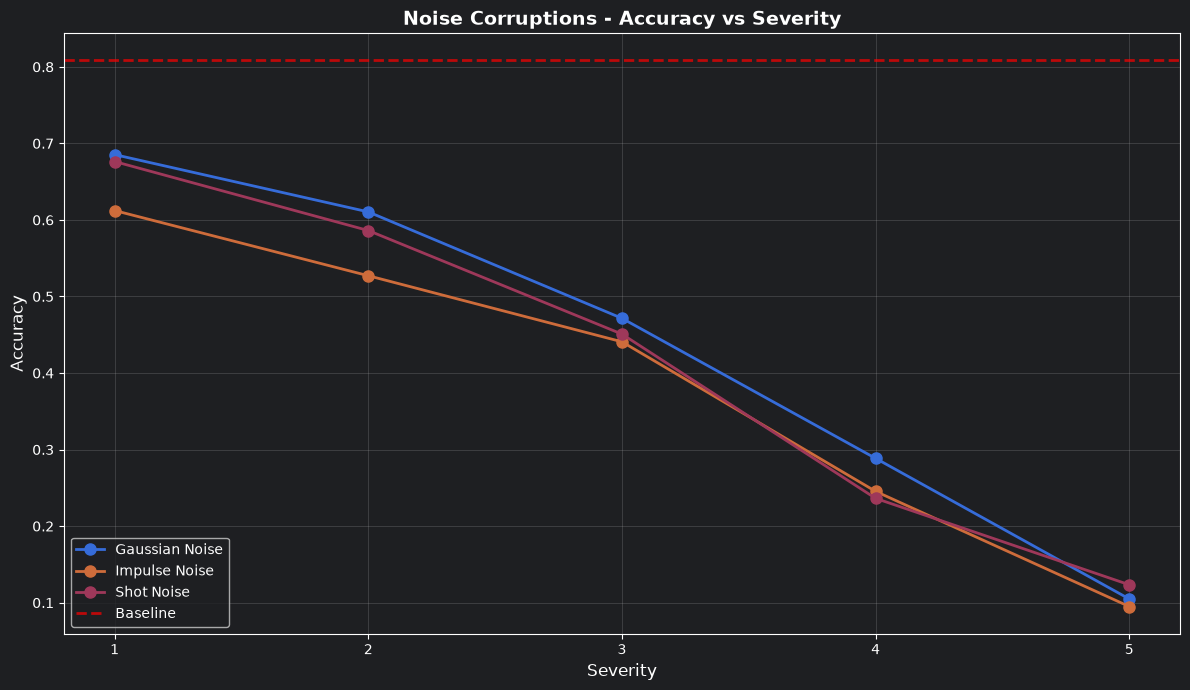

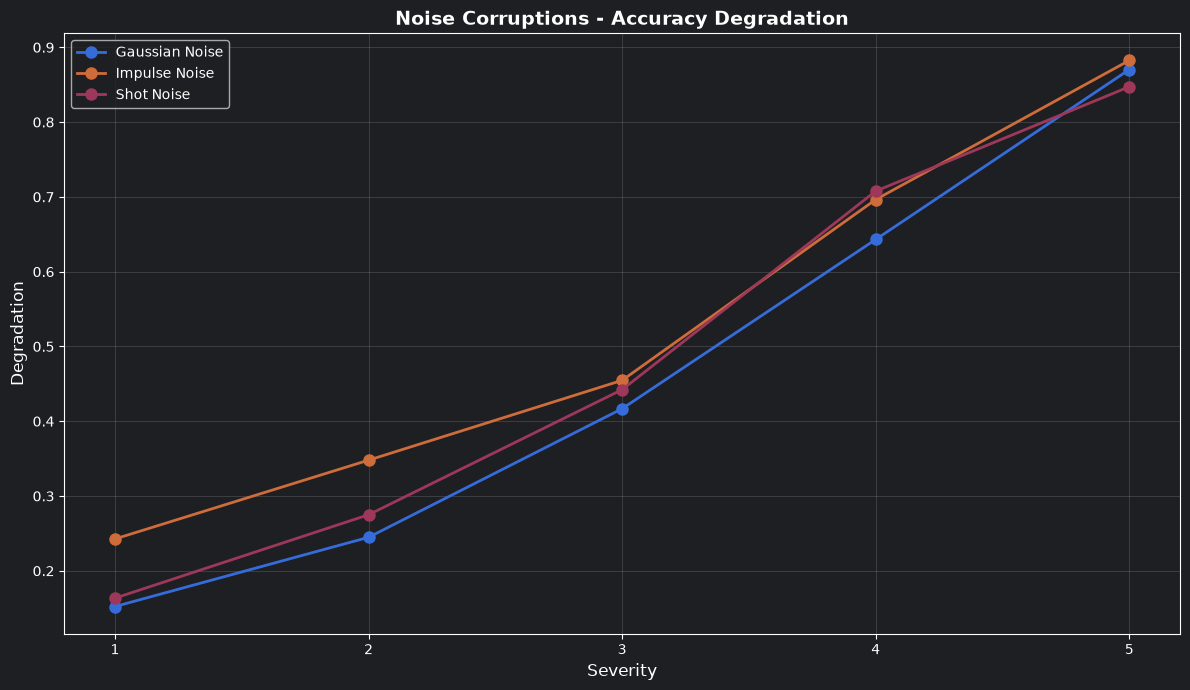

,corruption_type,AUC,slope,R_squared
0,gaussian_noise,0.534567,0.183439,0.976474
2,shot_noise,0.512860,0.180057,0.981790
1,impulse_noise,0.475161,0.162830,0.970340


In [85]:
plot_corruption_category("../results/ImageNetC", category='noise', metric_name='accuracy')
# AUC delle robustness (media rapporto accuracy a un severity level e baseline), non della degradation
summary_noise = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='noise',use_robustness=True)
plot_degradation(category='noise', metric_name='accuracy')
summary_noise

### Gaussian Noise

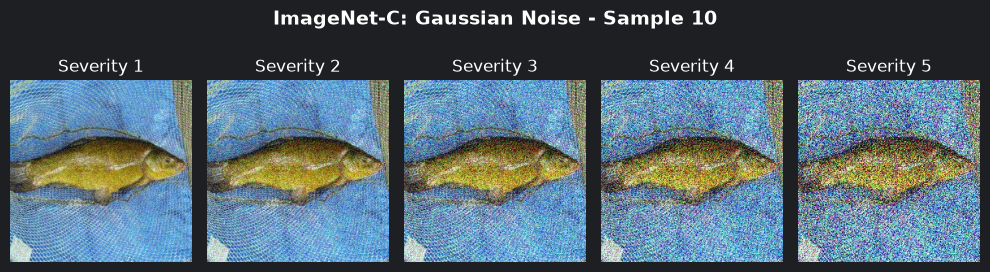

In [86]:
# show example of image with gaussian blur corruption at different severity levels
show_corruption_comparison("gaussian_noise", random_idx=False, sample_idx= idx)

### Shot Noise

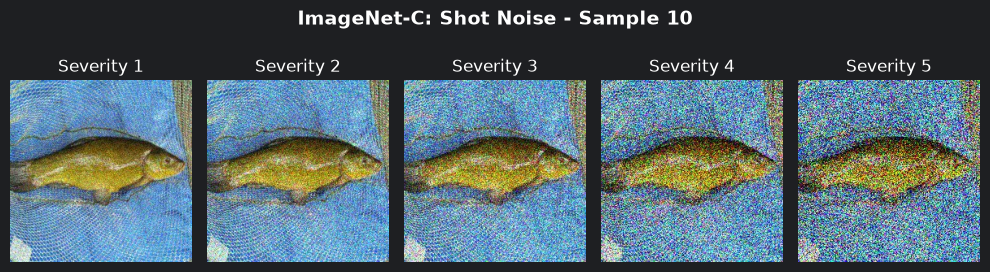

In [87]:
# show example of image with shot noise corruption at different severity levels
show_corruption_comparison("shot_noise", random_idx=False, sample_idx= idx)

### Impulse Noise

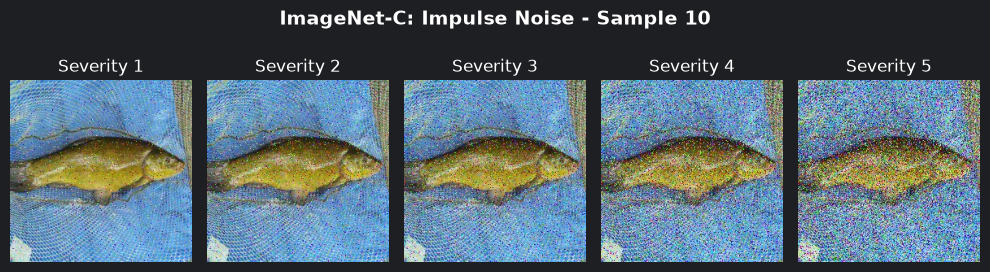

In [88]:
# show example of image with impulse noise corruption at different severity levels
show_corruption_comparison("impulse_noise", random_idx=False, sample_idx= idx)

## Blur
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with blur corruption. The different types of blur corruption are: defocus_blur, glass_blur, motion_blur, and zoom_blur.

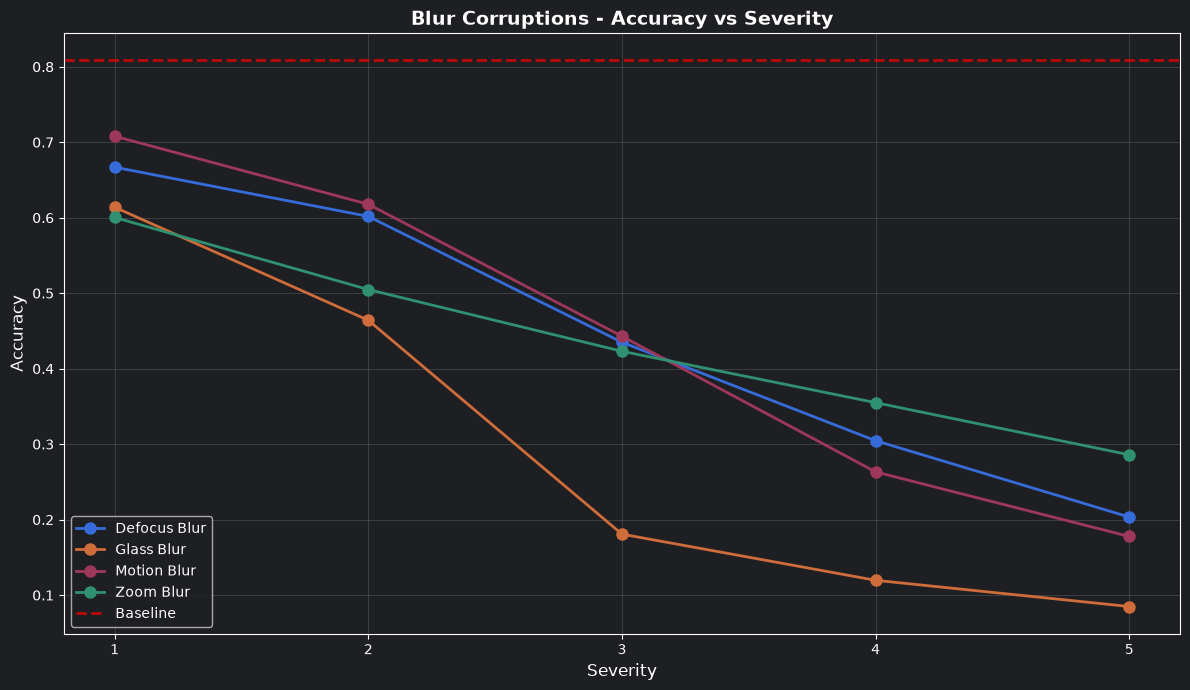

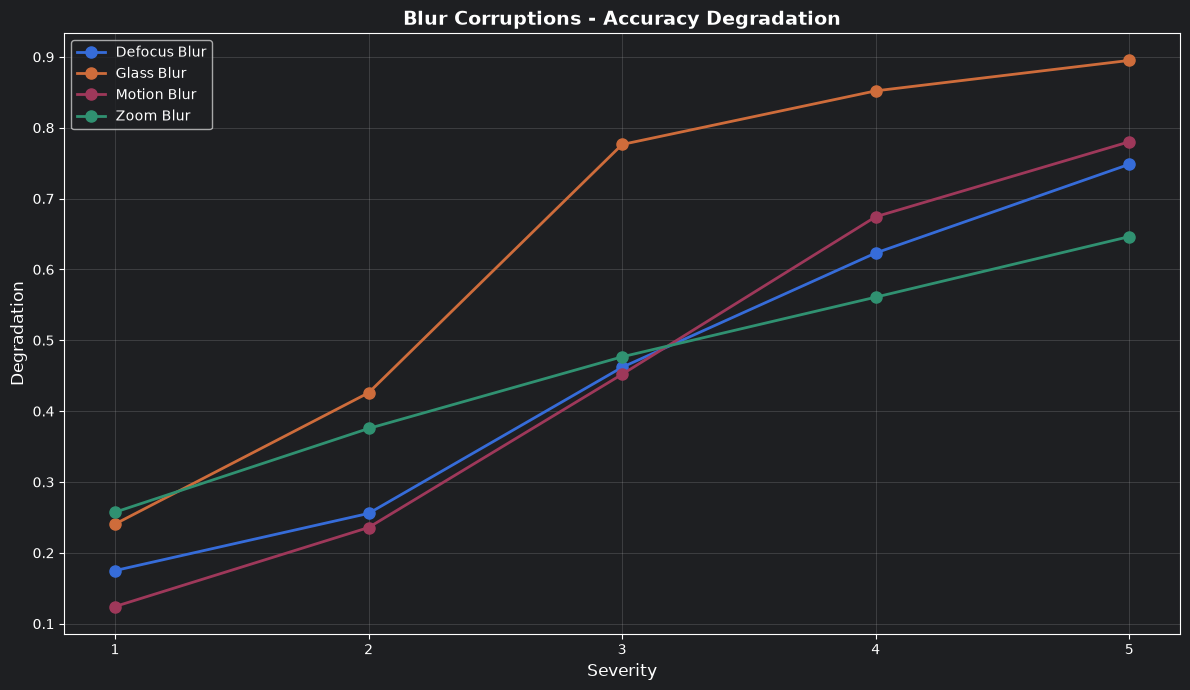

,corruption_type,AUC,slope,R_squared
0,defocus_blur,0.547165,0.151442,0.986188
2,motion_blur,0.546680,0.175052,0.984230
3,zoom_blur,0.536640,0.096331,0.994401
1,glass_blur,0.362009,0.173483,0.901419


In [89]:
plot_corruption_category("../results/ImageNetC", category='blur', metric_name='accuracy')
summary_blur = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='blur',use_robustness=True)
plot_degradation(category='blur', metric_name='accuracy')
summary_blur

### Defocus Blur

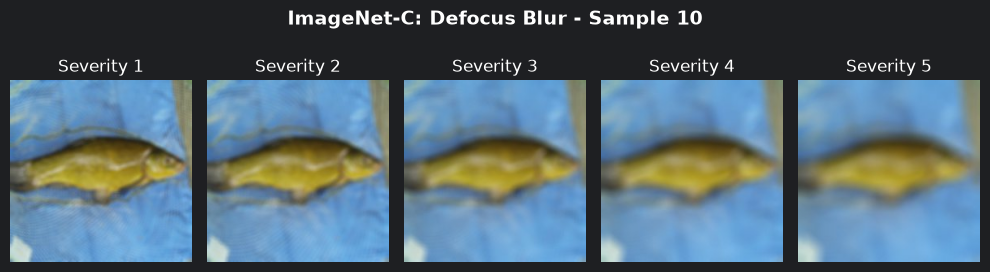

In [90]:
# show example of image with defocus blur corruption at different severity levels
show_corruption_comparison("defocus_blur", random_idx=False, sample_idx= idx)

### Glass Blur

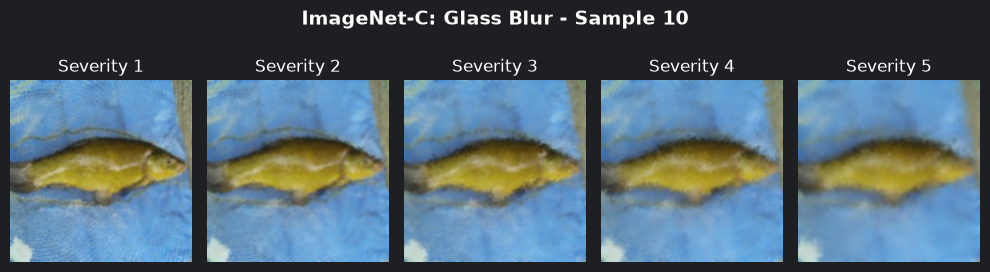

In [91]:
# show example of image with glass blur corruption at different severity levels
show_corruption_comparison("glass_blur", random_idx=False, sample_idx= idx)

### Motion Blur

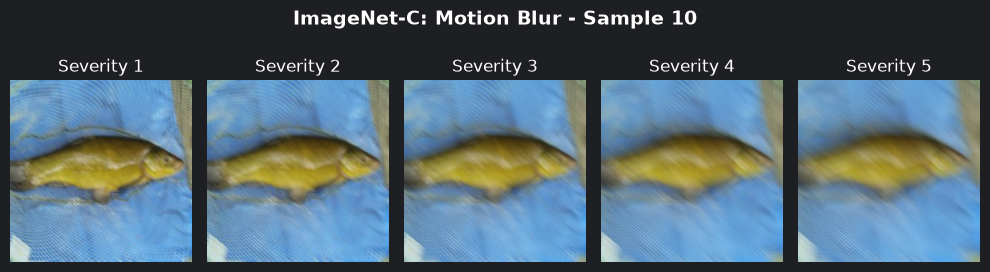

In [92]:
# show example of image with motion blur corruption at different severity levels
show_corruption_comparison("motion_blur", random_idx=False, sample_idx= idx)

### Zoom Blur

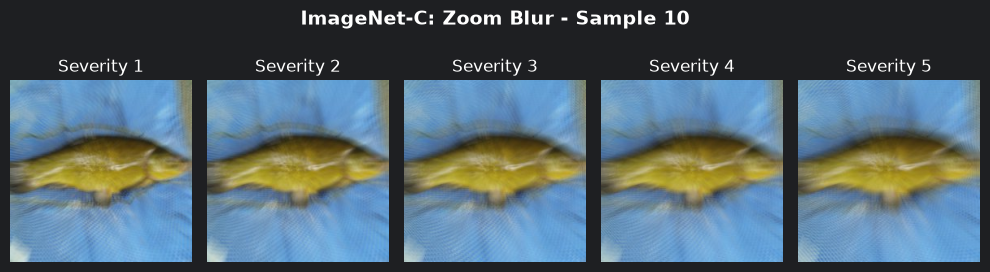

In [93]:
# show example of image with zoom blur corruption at different severity levels
show_corruption_comparison("zoom_blur", random_idx=False, sample_idx= idx)

## Weather
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with weather corruption. The different types of weather corruption are: snow, frost, fog, and brightness.

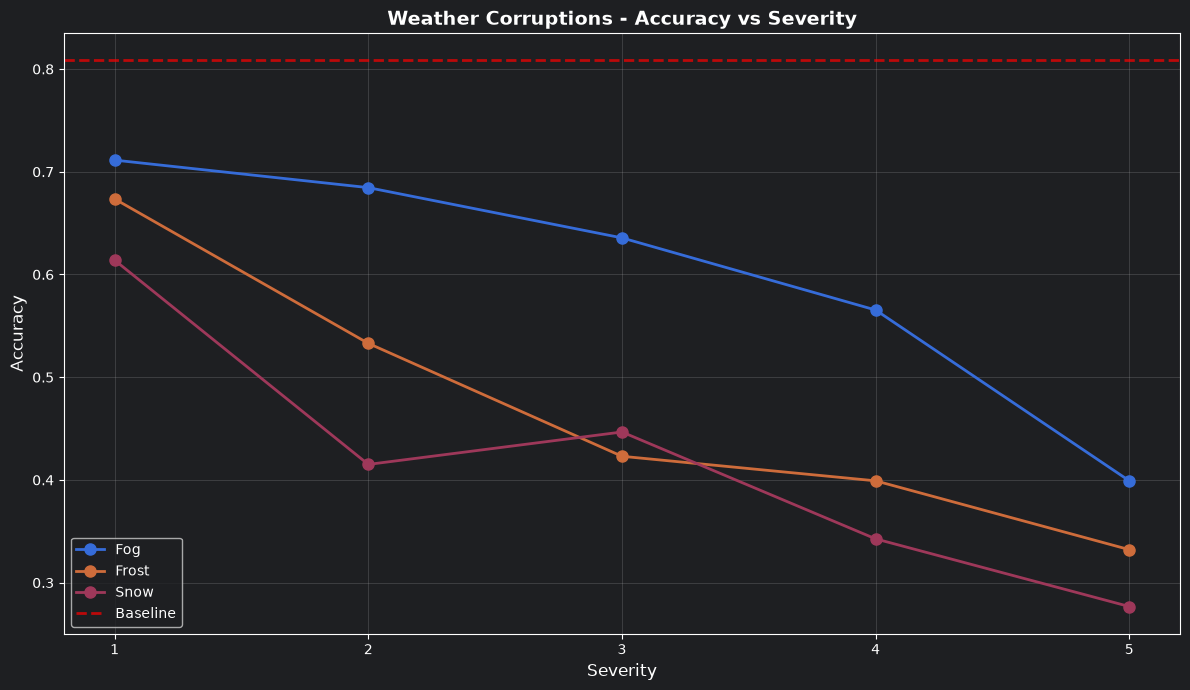

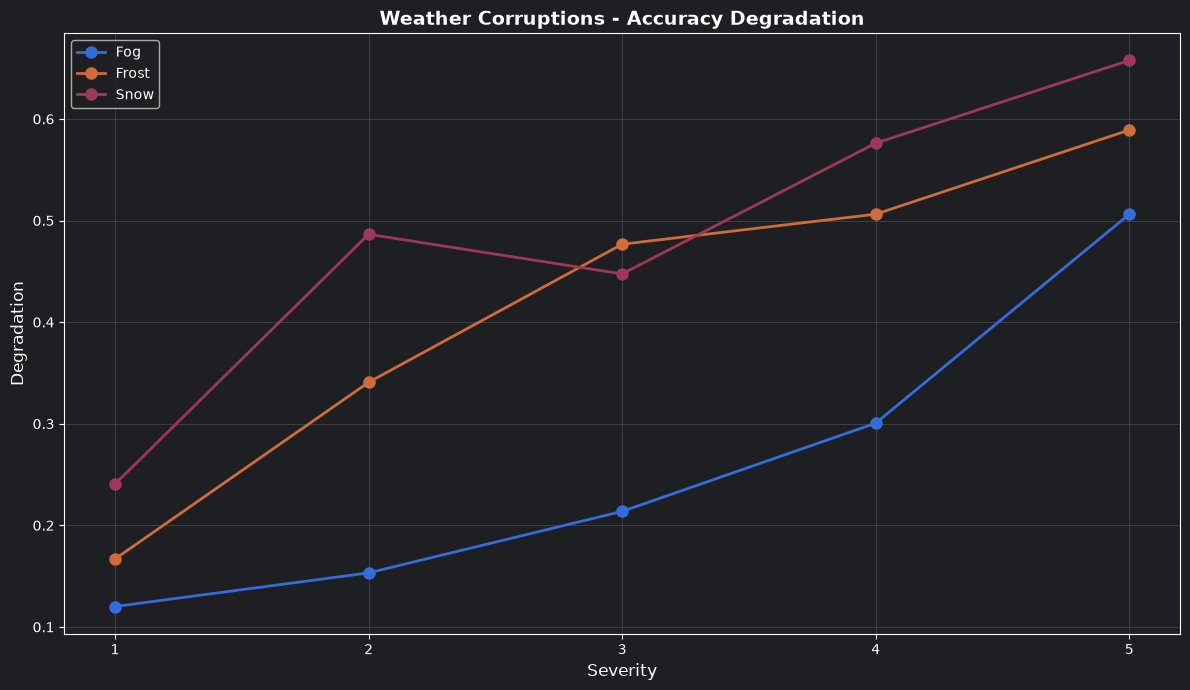

,corruption_type,AUC,slope,R_squared
0,fog,0.741252,0.091967,0.886661
1,frost,0.584067,0.101004,0.931350
2,snow,0.518337,0.092370,0.860153


In [94]:
plot_corruption_category("../results/ImageNetC", category='weather', metric_name='accuracy')
summary_weather = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='weather',use_robustness=True)
plot_degradation(category='weather', metric_name='accuracy')
summary_weather

### Snow

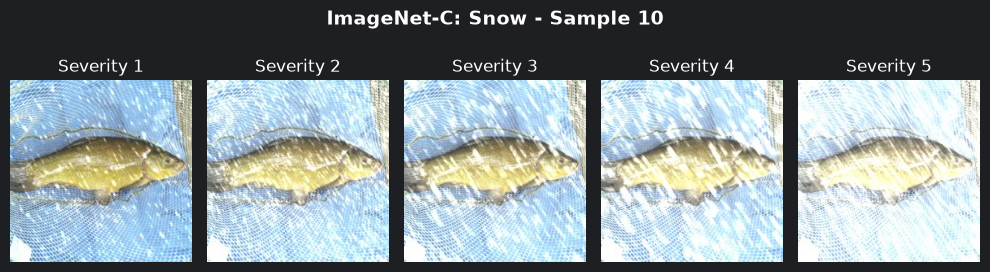

In [95]:
# show example of image with snow corruption at different severity levels
show_corruption_comparison("snow", random_idx=False, sample_idx= idx)

### Frost

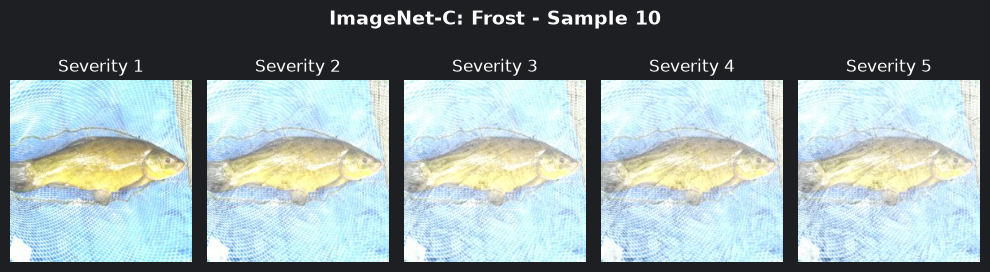

In [96]:
# show example of image with frost corruption at different severity levels
show_corruption_comparison("frost", random_idx=False, sample_idx= idx)

### Fog

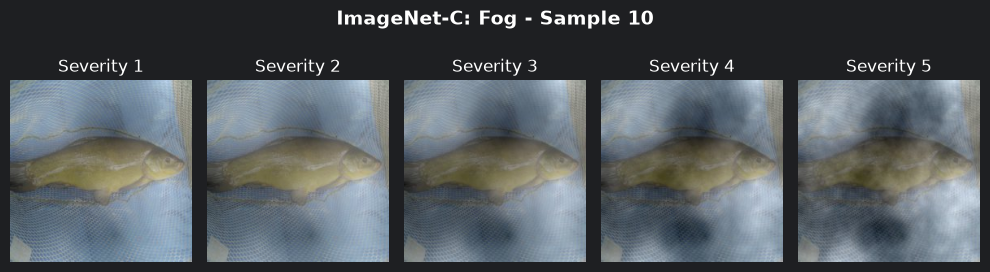

In [97]:
# show example of image with fog corruption at different severity levels
show_corruption_comparison("fog", random_idx=False, sample_idx= idx)

## Digital
Here we evaluate the metrics of a model on ImageNet-1k and ImageNet-C with digital corruption. The different types of digital corruption are: contrast, elastic_transform, pixelate, and jpeg_compression and brightness.

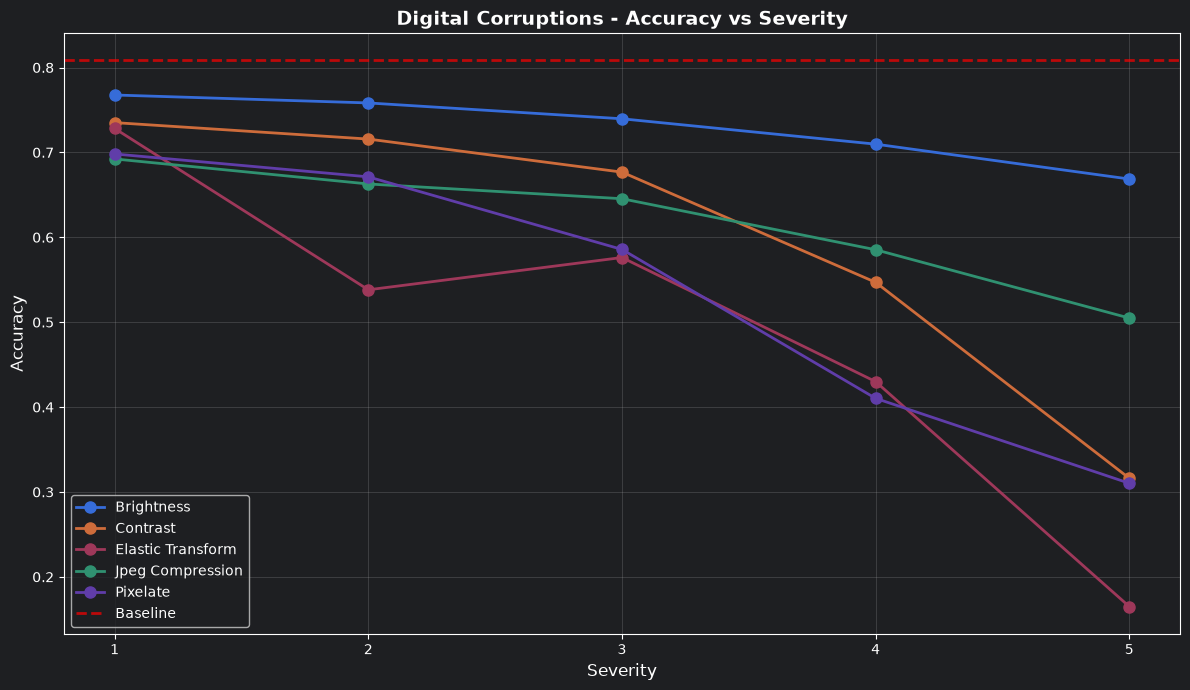

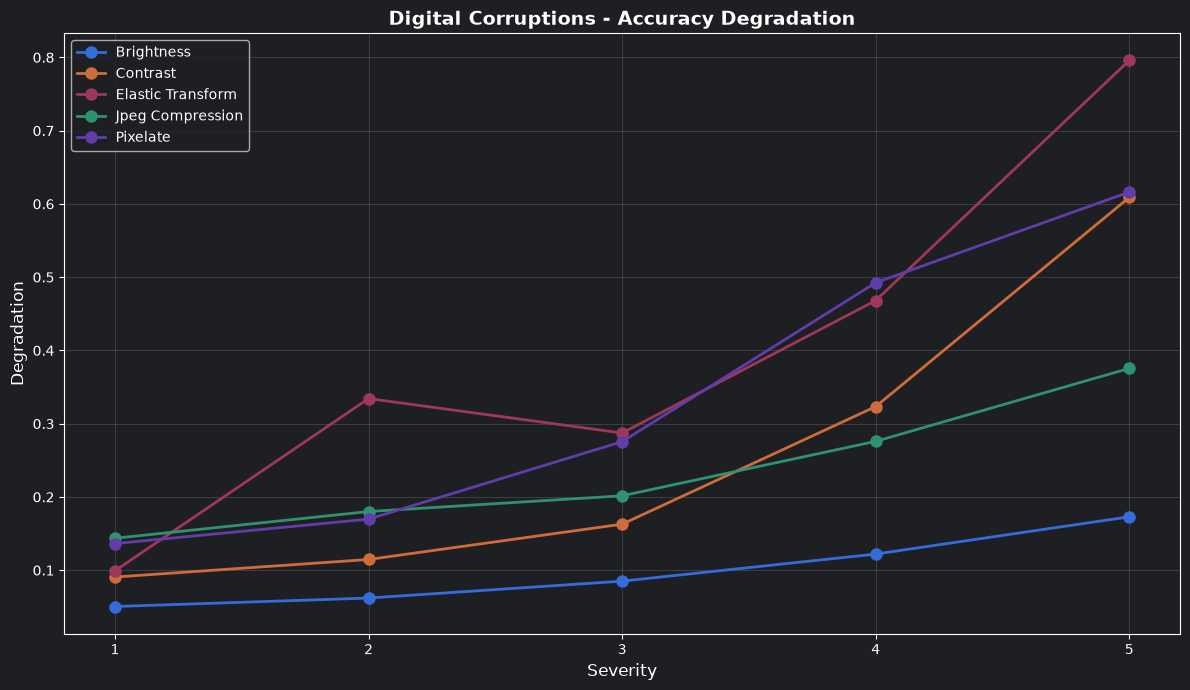

,corruption_type,AUC,slope,R_squared
0,brightness,0.901539,0.030497,0.938399
3,jpeg_compression,0.764681,0.055962,0.923831
1,contrast,0.739926,0.124527,0.838165
4,pixelate,0.661954,0.128256,0.944419
2,elastic_transform,0.603058,0.152719,0.867600


In [98]:
plot_corruption_category("../results/ImageNetC", category='digital', metric_name='accuracy')
summary_digital = degradation_summary("../results/ImageNetC", metric_name='accuracy', category='digital',use_robustness=True)
plot_degradation(category='digital', metric_name='accuracy')
summary_digital

### Brightness

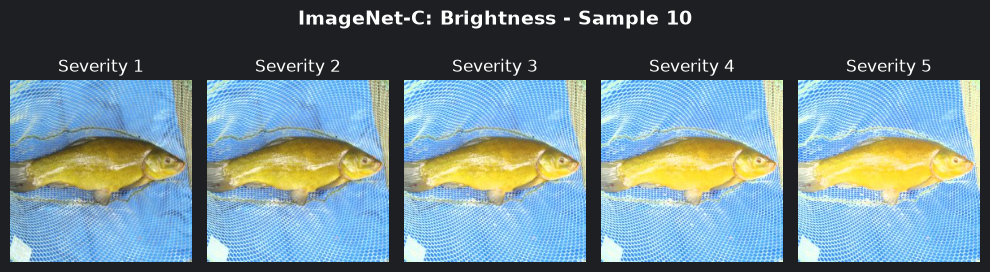

In [99]:
# show example of image with brightness corruption at different severity levels
show_corruption_comparison("brightness", random_idx=False, sample_idx= idx)

### Contrast

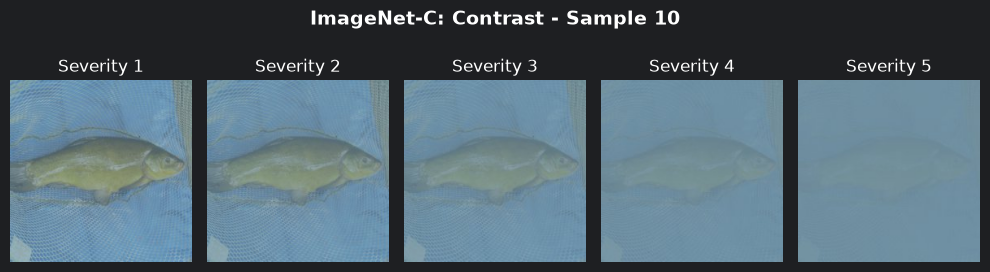

In [100]:
# show example of image with contrast corruption at different severity levels
show_corruption_comparison("contrast", random_idx=False, sample_idx= idx)

### Elastic transformation

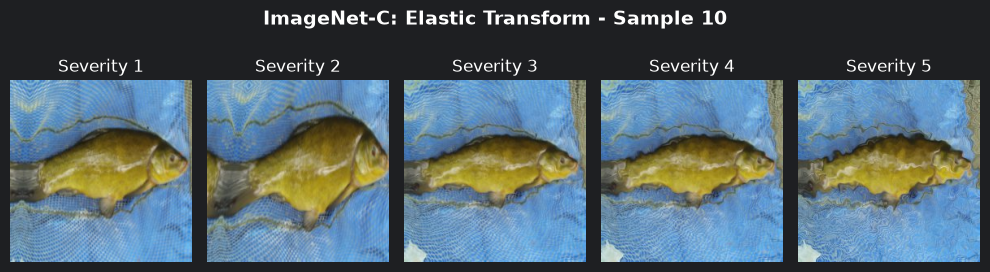

In [101]:
# show example of image with elastic_transform corruption at different severity levels
show_corruption_comparison("elastic_transform", random_idx=False, sample_idx= idx)

### Jpeg compression

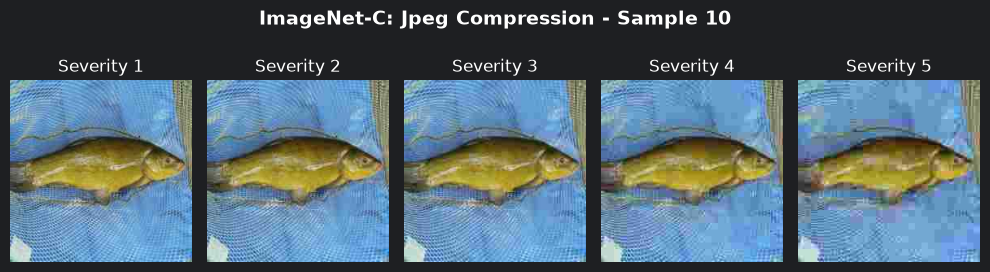

In [102]:
# show example of image with jpeg_compression corruption at different severity levels
show_corruption_comparison("jpeg_compression", random_idx=False, sample_idx= idx)

### Pixelate

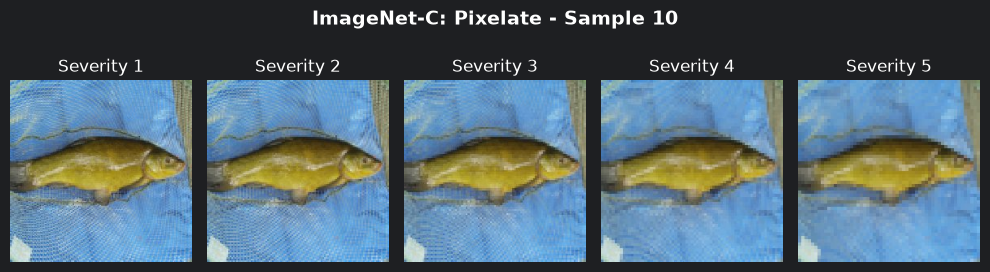

In [103]:
# show example of image with pixelate corruption at different severity levels
show_corruption_comparison("pixelate", random_idx=False, sample_idx= idx)

## Summary

In [104]:
# Tutte le corruzioni
summary_all = degradation_summary("../results/ImageNetC", metric_name='accuracy',use_robustness=True)
summary_all

,corruption_type,AUC,slope,R_squared
0,brightness,0.901539,0.030497,0.938399
9,jpeg_compression,0.764681,0.055962,0.923831
4,fog,0.741252,0.091967,0.886661
1,contrast,0.739926,0.124527,0.838165
11,pixelate,0.661954,0.128256,0.944419
3,elastic_transform,0.603058,0.152719,0.867600
5,frost,0.584067,0.101004,0.931350
2,defocus_blur,0.547165,0.151442,0.986188
10,motion_blur,0.546680,0.175052,0.984230
14,zoom_blur,0.536640,0.096331,0.994401
